<a href="https://colab.research.google.com/github/Maryam-Skaik/ds-fundamentals-attrition-project/blob/main/ds_fundamentals_attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition

## Data Cleaning & Exploration
This notebook covers the full workflow for cleaning, exploring, and understanding the Employee Attrition dataset.

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
pd.set_option('display.max_columns', 50)

## Load Data

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/Course 1/Belt_Exam/Data/Mod_employee_attrition - Temp employee_attrition.csv'
df = pd.read_csv(fpath)
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,DailyRate,WeeklyRate,YearlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,752,3760,195520,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,NaN,61,2,2,Research Scientist,2,Married,488,2440,126880,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,NaN,92,2,1,Laboratory Technician,3,Single,736,3680,191360,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,448,2240,116480,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,NaN,40,3,1,Laboratory Technician,2,Married,320,1600,83200,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### Reorder Columns

In [ ]:
# Reorder columns
new_order = [
    # Employee Demographics
    'EmployeeNumber', 'Age', 'Gender', 'MaritalStatus', 'DistanceFromHome', 'Education', 'EducationField',

    # Job Role & Department
    'Department', 'JobRole', 'JobLevel', 'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'BusinessTravel', 'OverTime',

    # Compensation & Performance
    'HourlyRate', 'DailyRate', 'YearlyRate', 'PercentSalaryHike', 'StockOptionLevel', 'PerformanceRating',

    # Work Experience & Tenure
    'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',

    # Constants / Flags
    'EmployeeCount', 'StandardHours', 'Over18',

    # Target
    'Attrition'
]

df = df[new_order]
df.head()

,EmployeeNumber,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,BusinessTravel,OverTime,HourlyRate,DailyRate,YearlyRate,PercentSalaryHike,StockOptionLevel,PerformanceRating,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeCount,StandardHours,Over18,Attrition
0,1,41,Female,Single,1,2,Life Sciences,Sales,Sales Executive,2,3,4,2,1,1,Travel_Rarely,Yes,94,752,195520,11,0,3,8,8,0,6,4,0,5,1,80,Y,Yes
1,2,49,NaN,Married,8,1,Life Sciences,Research & Development,Research Scientist,2,2,2,3,4,3,Travel_Frequently,No,61,488,126880,23,1,4,1,10,3,10,7,1,7,1,80,Y,No
2,4,37,NaN,Single,2,2,Other,Research & Development,Laboratory Technician,1,2,3,4,2,3,Travel_Rarely,Yes,92,736,191360,15,0,3,6,7,3,0,0,0,0,1,80,Y,Yes
3,5,33,Female,Married,3,4,Life Sciences,Research & Development,Research Scientist,1,3,3,4,3,3,Travel_Frequently,Yes,56,448,116480,11,0,3,1,8,3,8,7,3,0,1,80,Y,No
4,7,27,NaN,Married,2,1,Medical,Research & Development,Laboratory Technician,1,3,2,1,4,3,Travel_Rarely,No,40,320,83200,12,1,3,9,6,3,2,2,2,2,1,80,Y,No


At first look, the column names are consistent with the data dictionary, so there is no need to rename them.
I have reordered the columns to improve readability, in the following groups:

1. Employee Demographics
2. Job Role & Department
3. Compensation & Performance
4. Work Experience & Tenure
5. Constants / Flags
6. Target Column: `Attrition`

By examining the data, we see that the dataset studies employee attrition, whether an employee will stay in their job or leave, based on several features related to personal life, education, work environment, and performance. The final outcome is recorded as `Yes` or `No`.

## Understanding the dataset


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1475 non-null   int64 
 1   Age                       1475 non-null   int64 
 2   Gender                    590 non-null    object
 3   MaritalStatus             1475 non-null   object
 4   DistanceFromHome          1475 non-null   int64 
 5   Education                 1475 non-null   int64 
 6   EducationField            1475 non-null   object
 7   Department                1475 non-null   object
 8   JobRole                   1475 non-null   object
 9   JobLevel                  1475 non-null   int64 
 10  JobInvolvement            1475 non-null   int64 
 11  JobSatisfaction           1475 non-null   int64 
 12  EnvironmentSatisfaction   1475 non-null   int64 
 13  RelationshipSatisfaction  1475 non-null   int64 
 14  WorkLifeBalance         

Now, using `df.info()`, the dataset consists of 34 columns and 1,475 rows.  

- Most columns have no missing values, except:
  - `Gender` has around 2/3 of data missing (590/1,475), so we need to consider how to handle missing values (drop, impute, etc.).  

- Regarding data types: most features are consistent with the data dictionary, except that `HourlyRate` and `YearsAtCompany` are marked as objects, whereas they should be numeric (`int` or `float`).

In [ ]:
df.describe().round(2)

,EmployeeNumber,Age,DistanceFromHome,Education,JobLevel,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,DailyRate,YearlyRate,PercentSalaryHike,StockOptionLevel,PerformanceRating,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeCount,StandardHours
count,1475.00,1475.00,1475.0,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.00,1475.0,1475.0
mean,1023.98,37.29,9.2,2.91,2.07,2.73,2.73,2.72,2.71,2.76,526.99,137017.71,15.21,0.79,3.15,2.69,11.28,2.80,4.22,2.18,4.12,1.0,80.0
std,602.16,16.78,8.1,1.02,1.11,0.71,1.10,1.09,1.08,0.71,162.79,42325.71,3.66,0.85,0.36,2.50,7.78,1.29,3.62,3.22,3.57,0.0,0.0
min,1.00,18.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,240.00,62400.00,11.00,0.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,80.0
25%,489.50,30.00,2.0,2.00,1.00,2.00,2.00,2.00,2.00,2.00,384.00,99840.00,12.00,0.00,3.00,1.00,6.00,2.00,2.00,0.00,2.00,1.0,80.0
50%,1019.00,36.00,7.0,3.00,2.00,3.00,3.00,3.00,3.00,3.00,528.00,137280.00,14.00,1.00,3.00,2.00,10.00,3.00,3.00,1.00,3.00,1.0,80.0
75%,1555.50,43.00,14.0,4.00,3.00,3.00,4.00,4.00,4.00,3.00,668.00,173680.00,18.00,1.00,3.00,4.00,15.00,3.00,7.00,3.00,7.00,1.0,80.0
max,2068.00,578.00,29.0,5.00,5.00,4.00,4.00,4.00,4.00,4.00,800.00,208000.00,25.00,3.00,4.00,9.00,40.00,6.00,18.00,15.00,17.00,1.0,80.0


Using `df.describe()`, we observe the following:

- **Age** has an unusual maximum value (578), which is clearly an outlier and should be handled.  
- **StandardHours** has the same value (80) for all rows, indicating it is a constant column and may not provide useful information for modeling.  
- **EmployeeCount** is also constant with a value of 1, so it can be considered for removal.  
- **DistanceFromHome** Most employees live close to work (mean ~9 km).  
- **Education & JobLevel** Mostly lower levels (mean ~2–3).  
- **Satisfaction features** (`JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance`) Moderate on average (~2.7).  

## Handling duplicates, missing values, and inconsistencies

### Duplicates

In [ ]:
duplicated_rows = df.duplicated()
duplicated_rows.sum()

np.int64(5)

In [ ]:
df[duplicated_rows]

,EmployeeNumber,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,BusinessTravel,OverTime,HourlyRate,DailyRate,YearlyRate,PercentSalaryHike,StockOptionLevel,PerformanceRating,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeCount,StandardHours,Over18,Attrition
14,18,34,NaN,Divorced,19,2,Medical,Research & Development,Laboratory Technician,1,3,4,2,3,3,Travel_Rarely,No,93,744,193440,11,1,3,0,3,2,2,2,1,2,1,80,Y,No
159,214,58,Female,Married,9,3,Medical,Research & Development,Research Scientist,1,2,2,2,2,2,Travel_Rarely,Yes,75,600,156000,20,1,4,4,9,3,1,0,0,0,1,80,Y,No
625,859,32,NaN,Divorced,13,4,Life Sciences,Sales,Sales Executive,2,3,4,2,3,2,Travel_Rarely,No,73,584,151840,11,1,3,2,8,3,5,2,0,3,1,80,Y,No
815,1125,38,NaN,Single,2,2,Marketing,Sales,Sales Executive,3,3,2,4,3,3,Travel_Rarely,No,32,256,66560,16,0,3,7,10,2,1,0,0,0,1,80,Y,No
1145,1608,44,Female,Divorced,7,3,Medical,Research & Development,Research Director,5,3,4,2,4,2,Travel_Rarely,Yes,31,248,64480,14,1,3,0,23,4,22,7,1,10,1,80,Y,No


We have 5 rows with exact duplicates in all fields.

In [ ]:
df[df.duplicated(keep=False)]

,EmployeeNumber,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,BusinessTravel,OverTime,HourlyRate,DailyRate,YearlyRate,PercentSalaryHike,StockOptionLevel,PerformanceRating,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeCount,StandardHours,Over18,Attrition
13,18,34,NaN,Divorced,19,2,Medical,Research & Development,Laboratory Technician,1,3,4,2,3,3,Travel_Rarely,No,93,744,193440,11,1,3,0,3,2,2,2,1,2,1,80,Y,No
14,18,34,NaN,Divorced,19,2,Medical,Research & Development,Laboratory Technician,1,3,4,2,3,3,Travel_Rarely,No,93,744,193440,11,1,3,0,3,2,2,2,1,2,1,80,Y,No
158,214,58,Female,Married,9,3,Medical,Research & Development,Research Scientist,1,2,2,2,2,2,Travel_Rarely,Yes,75,600,156000,20,1,4,4,9,3,1,0,0,0,1,80,Y,No
159,214,58,Female,Married,9,3,Medical,Research & Development,Research Scientist,1,2,2,2,2,2,Travel_Rarely,Yes,75,600,156000,20,1,4,4,9,3,1,0,0,0,1,80,Y,No
624,859,32,NaN,Divorced,13,4,Life Sciences,Sales,Sales Executive,2,3,4,2,3,2,Travel_Rarely,No,73,584,151840,11,1,3,2,8,3,5,2,0,3,1,80,Y,No
625,859,32,NaN,Divorced,13,4,Life Sciences,Sales,Sales Executive,2,3,4,2,3,2,Travel_Rarely,No,73,584,151840,11,1,3,2,8,3,5,2,0,3,1,80,Y,No
814,1125,38,NaN,Single,2,2,Marketing,Sales,Sales Executive,3,3,2,4,3,3,Travel_Rarely,No,32,256,66560,16,0,3,7,10,2,1,0,0,0,1,80,Y,No
815,1125,38,NaN,Single,2,2,Marketing,Sales,Sales Executive,3,3,2,4,3,3,Travel_Rarely,No,32,256,66560,16,0,3,7,10,2,1,0,0,0,1,80,Y,No
1144,1608,44,Female,Divorced,7,3,Medical,Research & Development,Research Director,5,3,4,2,4,2,Travel_Rarely,Yes,31,248,64480,14,1,3,0,23,4,22,7,1,10,1,80,Y,No
1145,1608,44,Female,Divorced,7,3,Medical,Research & Development,Research Director,5,3,4,2,4,2,Travel_Rarely,Yes,31,248,64480,14,1,3,0,23,4,22,7,1,10,1,80,Y,No


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

We droped the 5 duplicated rows.

### Data Types

In [ ]:
for col in df.columns:
  print(f' {col}: {df[col].dtype}')

 EmployeeNumber: int64
 Age: int64
 Gender: object
 MaritalStatus: object
 DistanceFromHome: int64
 Education: int64
 EducationField: object
 Department: object
 JobRole: object
 JobLevel: int64
 JobInvolvement: int64
 JobSatisfaction: int64
 EnvironmentSatisfaction: int64
 RelationshipSatisfaction: int64
 WorkLifeBalance: int64
 BusinessTravel: object
 OverTime: object
 HourlyRate: object
 DailyRate: int64
 YearlyRate: int64
 PercentSalaryHike: int64
 StockOptionLevel: int64
 PerformanceRating: int64
 NumCompaniesWorked: int64
 TotalWorkingYears: int64
 TrainingTimesLastYear: int64
 YearsAtCompany: object
 YearsInCurrentRole: int64
 YearsSinceLastPromotion: int64
 YearsWithCurrManager: int64
 EmployeeCount: int64
 StandardHours: int64
 Over18: object
 Attrition: object


We found that **`HourlyRate`** and **`YearsAtCompany`** are currently of type `object`, but they should be converted to `int`.  

All other features are consistent with the data dictionary and their expected types.  

In [ ]:
df['HourlyRate'].value_counts()

,count
HourlyRate,
66,29
98,28
84,28
42,28
48,28
...,...
53,14
68,14
38,13


`94_` need to replace with `94`, so we can change data type

In [ ]:
df.loc[:, 'HourlyRate'] = df['HourlyRate'].str.replace('_', '').str.strip()
df['HourlyRate'].value_counts()

,count
HourlyRate,
66,29
84,28
42,28
98,28
48,28
...,...
89,15
53,14
68,14


In [ ]:
df['HourlyRate'] = df['HourlyRate'].astype(int)
df['HourlyRate'].dtype

dtype('int64')

In [ ]:
df['YearsAtCompany'].value_counts()

,count
YearsAtCompany,
5,195
1,171
3,128
2,127
10,120
4,110
7,90
9,82
8,80


Also here, we found `5!` instead of `5`

In [ ]:
df.loc[:, 'YearsAtCompany'] = df['YearsAtCompany'].str.replace('!', '').str.strip()
df['YearsAtCompany'].value_counts()

,count
YearsAtCompany,
5,196
1,171
3,128
2,127
10,120
4,110
7,90
9,82
8,80


In [ ]:
df['YearsAtCompany'] = df['YearsAtCompany'].astype(int)
df['YearsAtCompany'].dtype

dtype('int64')

In [ ]:
ordinal_columns = [
    'Education','EnvironmentSatisfaction','JobInvolvement','JobLevel',
    'JobSatisfaction','PerformanceRating','RelationshipSatisfaction',
    'WorkLifeBalance','StockOptionLevel'
]

for col in ordinal_columns:
    df[col] = pd.Categorical(df[col], ordered=True)

In [ ]:
categorical_col = df.select_dtypes(['object', 'category'])
categorical_col.columns

Index(['Gender', 'MaritalStatus', 'Education', 'EducationField', 'Department',
       'JobRole', 'JobLevel', 'JobInvolvement', 'JobSatisfaction',
       'EnvironmentSatisfaction', 'RelationshipSatisfaction',
       'WorkLifeBalance', 'BusinessTravel', 'OverTime', 'StockOptionLevel',
       'PerformanceRating', 'Over18', 'Attrition'],
      dtype='object')

In [ ]:
numeric_col = df.select_dtypes('number')
numeric_col.columns

Index(['EmployeeNumber', 'Age', 'DistanceFromHome', 'HourlyRate', 'DailyRate',
       'YearlyRate', 'PercentSalaryHike', 'NumCompaniesWorked',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'EmployeeCount', 'StandardHours'],
      dtype='object')

In [ ]:
for col in df.columns:
  print(f' {col}: {df[col].dtype}')

 EmployeeNumber: int64
 Age: int64
 Gender: object
 MaritalStatus: object
 DistanceFromHome: int64
 Education: category
 EducationField: object
 Department: object
 JobRole: object
 JobLevel: category
 JobInvolvement: category
 JobSatisfaction: category
 EnvironmentSatisfaction: category
 RelationshipSatisfaction: category
 WorkLifeBalance: category
 BusinessTravel: object
 OverTime: object
 HourlyRate: int64
 DailyRate: int64
 YearlyRate: int64
 PercentSalaryHike: int64
 StockOptionLevel: category
 PerformanceRating: category
 NumCompaniesWorked: int64
 TotalWorkingYears: int64
 TrainingTimesLastYear: int64
 YearsAtCompany: int64
 YearsInCurrentRole: int64
 YearsSinceLastPromotion: int64
 YearsWithCurrManager: int64
 EmployeeCount: int64
 StandardHours: int64
 Over18: object
 Attrition: object


### Categorical inconsistencies

In [ ]:
df['Gender'].value_counts(dropna=False)

,count
Gender,
NaN,882
Female,588


We found that the `Gender` feature contains only **Female** values, and the rest are missing (NaN).  
So, we will impute the missing values with a placeholder `MISSING`.  

We cannot fill all missing values with "Male", as this may bias the data and affect modeling and evaluation.  
Also, since the feature has only one observed value (Female) plus NaN, we cannot use mode imputation, even when grouping by other correlated features.

In [ ]:
df['Age'].value_counts()

,count
Age,
35,78
34,77
31,69
36,69
29,68
32,61
30,60
38,58
33,58


In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].replace(578, int(df['Age'].mean()))
df['Age'] = df['Age'].astype(int)

df['Age'].dtype, df['Age'].value_counts()

(dtype('int64'),
 Age
 35    78
 34    77
 36    69
 31    69
 29    68
 32    61
 30    60
 38    58
 33    58
 40    57
 37    51
 28    48
 27    48
 42    46
 39    42
 45    41
 41    40
 26    39
 44    33
 46    33
 43    32
 50    30
 25    26
 24    26
 49    24
 47    24
 55    22
 48    19
 51    19
 53    19
 54    18
 52    18
 22    16
 23    14
 56    14
 58    13
 21    13
 20    11
 59    10
 19     9
 18     8
 60     5
 57     4
 Name: count, dtype: int64)

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
df['BusinessTravel'].value_counts()

,count
BusinessTravel,
Travel_Rarely,1043
Travel_Frequently,277
Non-Travel,150


In [ ]:
df['Department'].value_counts()

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


In [ ]:
df['EducationField'].value_counts()

,count
EducationField,
Life Sciences,606
Medical,464
Marketing,159
Technical Degree,132
Other,82
Human Resources,27


In [ ]:
df['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


In [ ]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,673
Single,470
Divorced,327


In [ ]:
df['Over18'].value_counts()

,count
Over18,
Y,1470


Here we note another constant column and may not provide useful information for modeling.

In [ ]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [ ]:
df['Education'].value_counts()

,count
Education,
3,572
4,398
2,282
1,170
5,48


In [ ]:
df['EnvironmentSatisfaction'].value_counts()

,count
EnvironmentSatisfaction,
3,453
4,446
2,287
1,284


In [ ]:
df['JobSatisfaction'].value_counts()

,count
JobSatisfaction,
4,459
3,442
1,289
2,280


In [ ]:
df['RelationshipSatisfaction'].value_counts()

,count
RelationshipSatisfaction,
3,459
4,432
2,303
1,276


In [ ]:
df['WorkLifeBalance'].value_counts()

,count
WorkLifeBalance,
3,893
2,344
4,153
1,80


In [ ]:
df['JobInvolvement'].value_counts()

,count
JobInvolvement,
3,868
2,375
4,144
1,83


In [ ]:
df['PerformanceRating'].value_counts()

,count
PerformanceRating,
3,1244
4,226


In [ ]:
df['StockOptionLevel'].value_counts()

,count
StockOptionLevel,
0,631
1,596
2,158
3,85


For all checked features, we found that they are consistent with the data dictionary.  

One important observation is that the `Over18` column is also considered a constant feature, since all its values are `Yes`.  

Another observation is that `PerformanceRating` contains only values 3 and 4 across all data, which indicates generally high performance ratings among employees.

### Handling Constant / Non-Informative Features

In [ ]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])
df.columns

Index(['EmployeeNumber', 'Age', 'Gender', 'MaritalStatus', 'DistanceFromHome',
       'Education', 'EducationField', 'Department', 'JobRole', 'JobLevel',
       'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction',
       'RelationshipSatisfaction', 'WorkLifeBalance', 'BusinessTravel',
       'OverTime', 'HourlyRate', 'DailyRate', 'YearlyRate',
       'PercentSalaryHike', 'StockOptionLevel', 'PerformanceRating',
       'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition'],
      dtype='object')

We identified 3 constant features in the dataset `EmployeeCount`, `StandardHours`, `Over18`.

These features don't provide any variability, so we dropped them.

### Missing Values

In [ ]:
df.isna().sum()

,0
EmployeeNumber,0
Age,0
Gender,882
MaritalStatus,0
DistanceFromHome,0
Education,0
EducationField,0
Department,0
JobRole,0
JobLevel,0


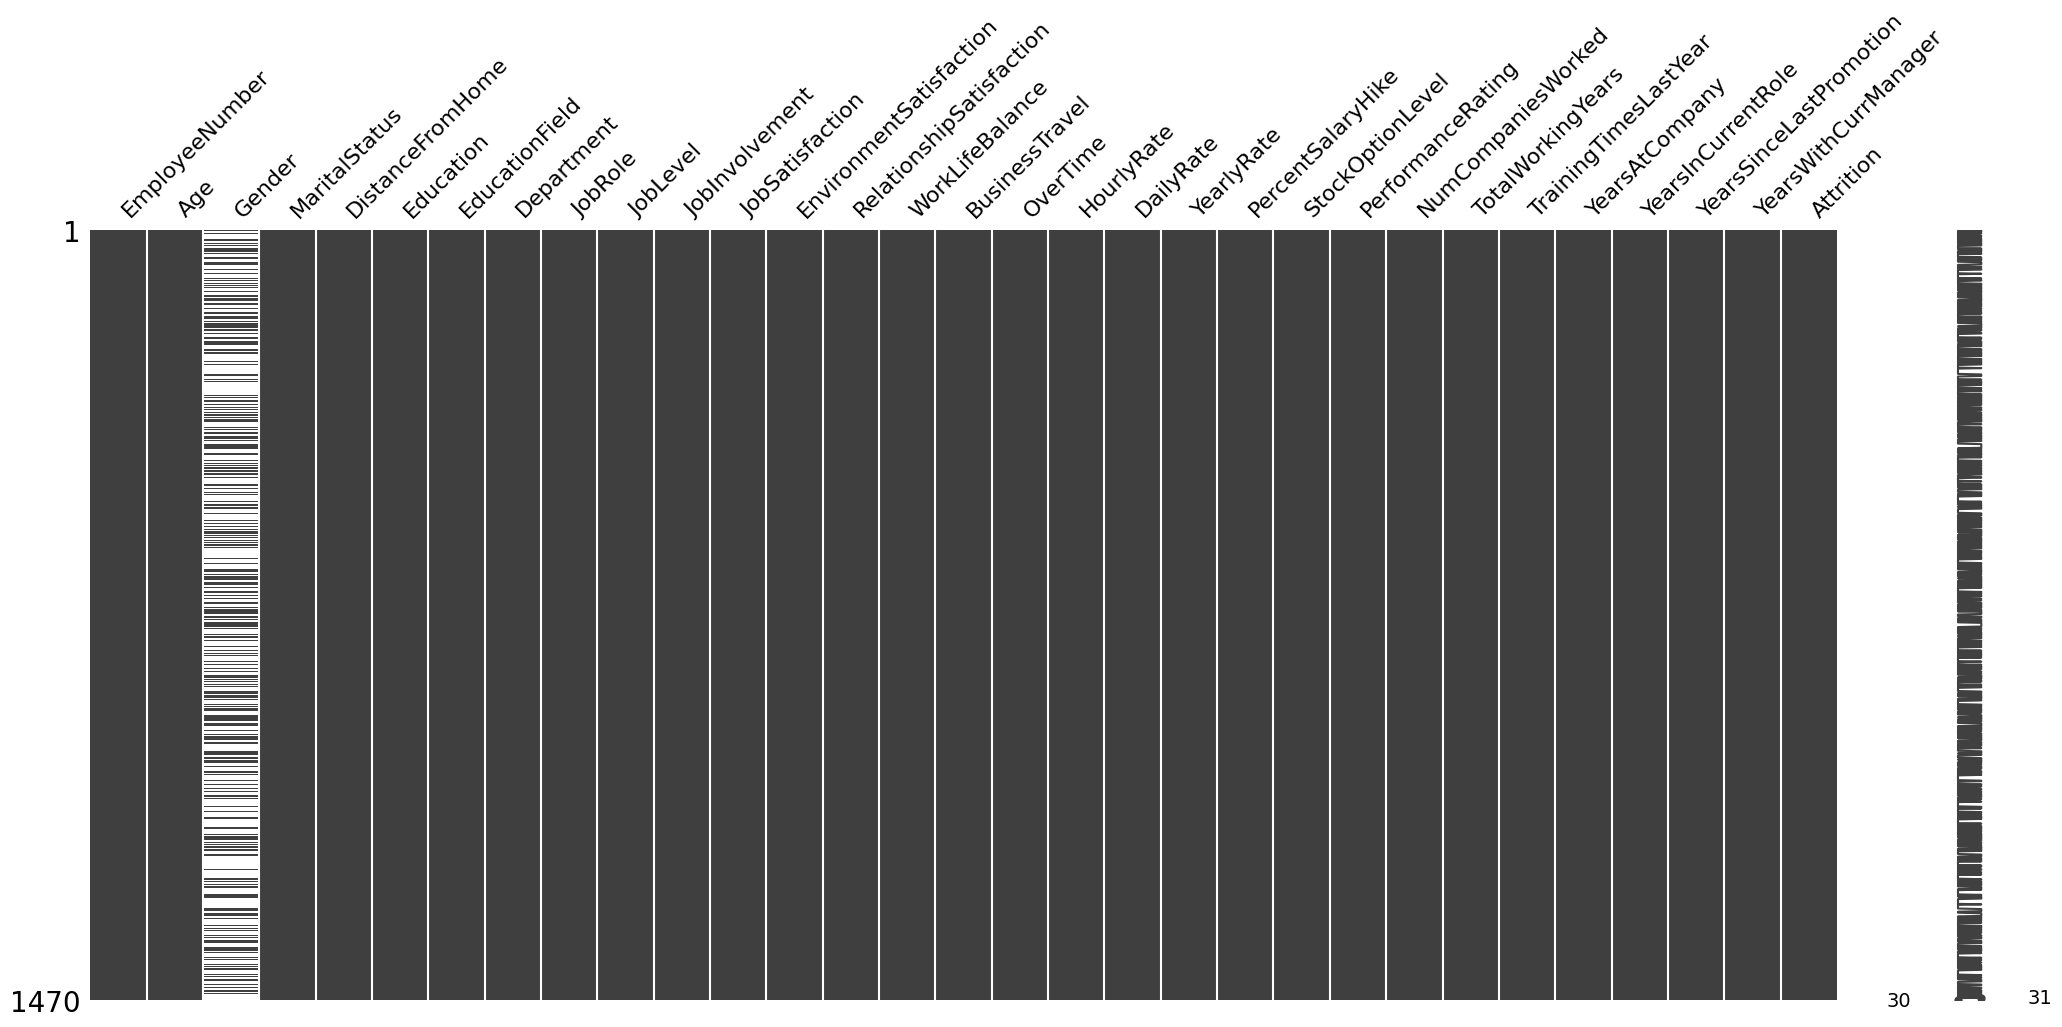

In [ ]:
import missingno as msno
msno.matrix(df);

As noted earlier, `Gender` is the only column that has missing values, so we will impute it using the `MISSING` placeholder.

In [ ]:
df['Gender'] = df['Gender'].fillna('MISSING')

In [ ]:
df.isna().sum()

,0
EmployeeNumber,0
Age,0
Gender,0
MaritalStatus,0
DistanceFromHome,0
Education,0
EducationField,0
Department,0
JobRole,0
JobLevel,0


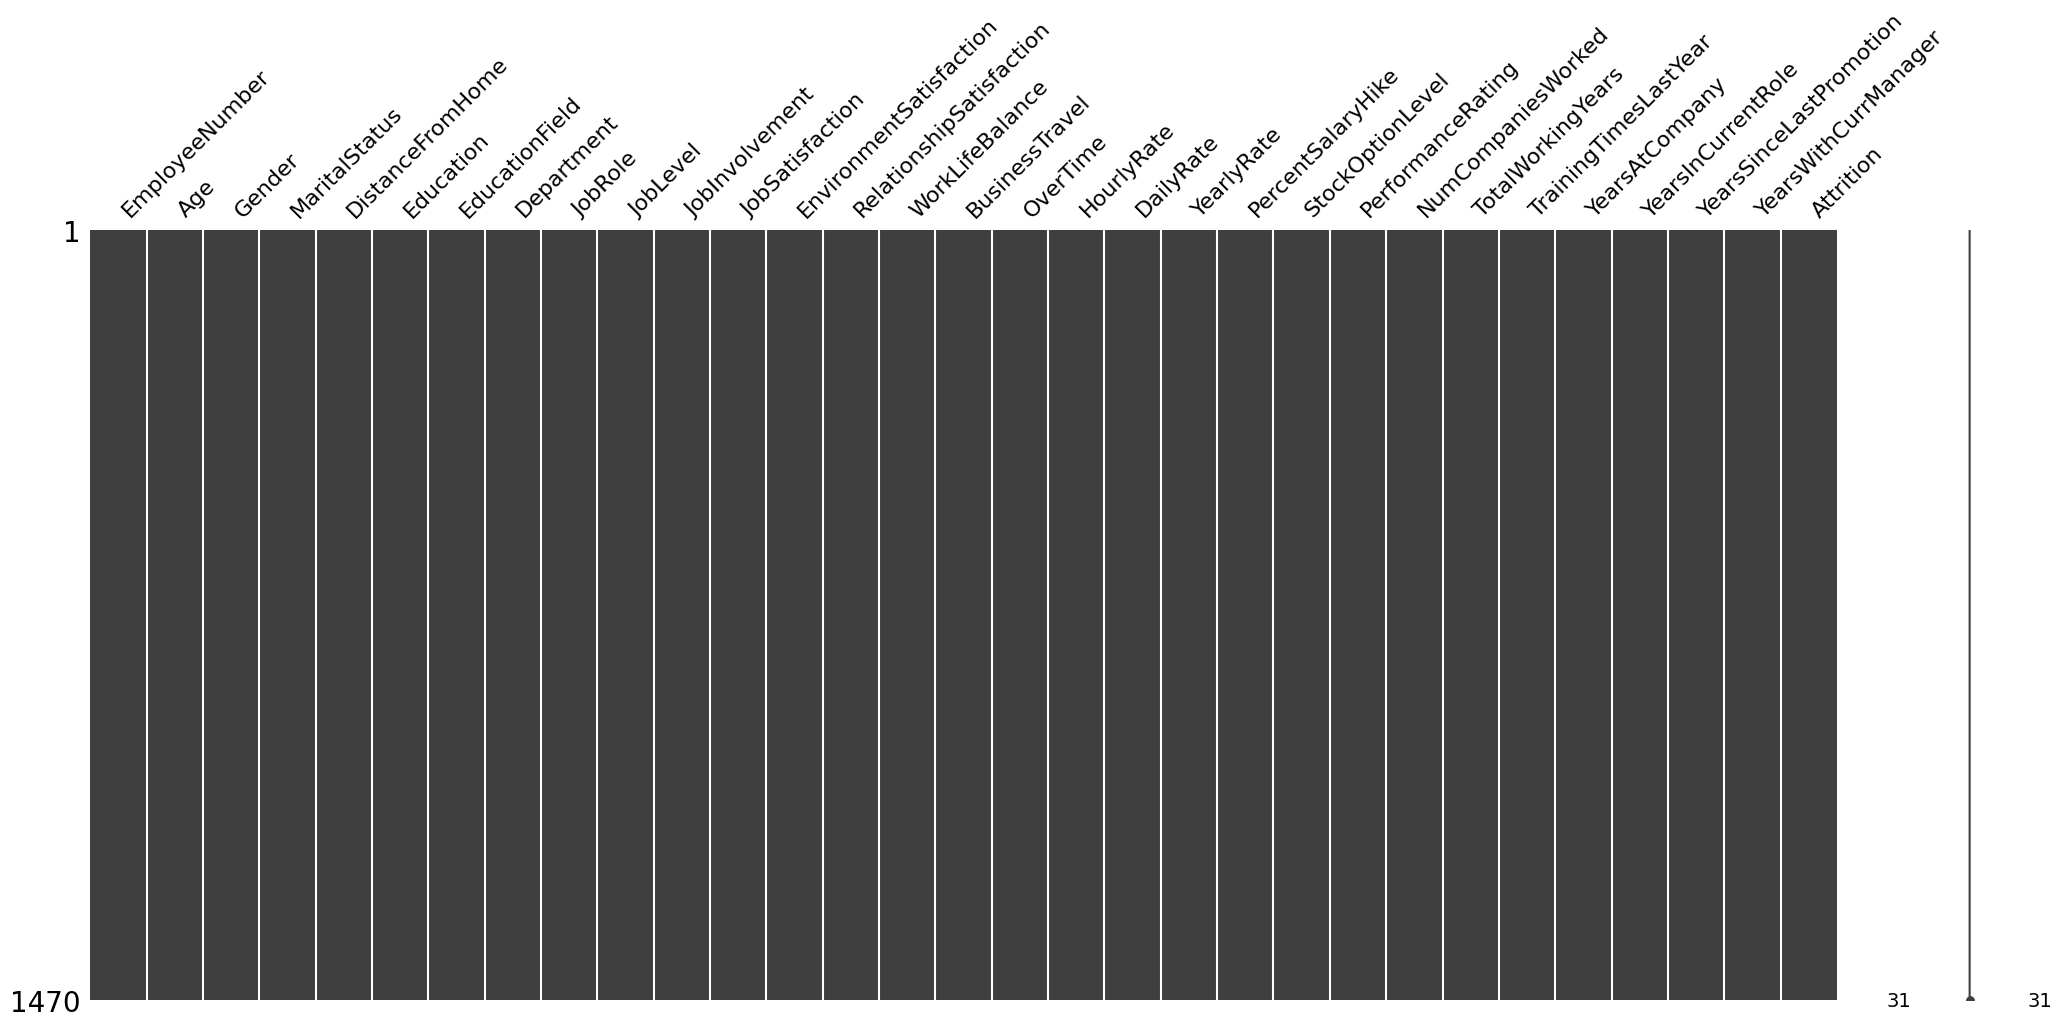

In [ ]:
msno.matrix(df);

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
# Basic imports for functions
import matplotlib.pyplot as plt
import seaborn as sns

# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = False, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.tick_params(axis='x', rotation=45)
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

In [ ]:
def plot_categorical_vs_target(df, x, y='Attrition', figsize=(6,4),
                                    fillna=True, placeholder='MISSING',
                                    order=None):
    """
    Plots the mean of a binary target per category.
    """
    temp_df = df.copy()

    # Convert target to 0/1 if not numeric
    if temp_df[y].dtype == 'object':
        temp_df[y] = temp_df[y].map({'No': 0, 'Yes': 1})

    if fillna:
        temp_df[x] = temp_df[x].fillna(placeholder)
    else:
        temp_df = temp_df.dropna(subset=[x])

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(data=temp_df, x=x, y=y, order=order, palette='Set2', alpha=0.7, edgecolor='black')

    ax.set_ylabel(f"Proportion of {y} = Yes")
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"{x} vs {y} (mean)", fontweight='bold')
    fig.tight_layout()

    return fig, ax


def plot_numeric_vs_target(df, x, y='Attrition', figsize=(6,4)):
    """Plots numeric feature distribution grouped by categorical target."""
    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(data=df, x=y, y=x, ax=ax, palette='Set3')
    sns.stripplot(data=df, x=y, y=x, ax=ax, color='gray', alpha=0.4, size=3, jitter=True)

    # Add medians in title
    medians = df.groupby(y)[x].median()
    ax.set_title(f"{x} distribution by {y} (medians: {medians.to_dict()})", fontweight='bold')

    fig.tight_layout()
    return fig, ax

## Understanding distributions of individual features

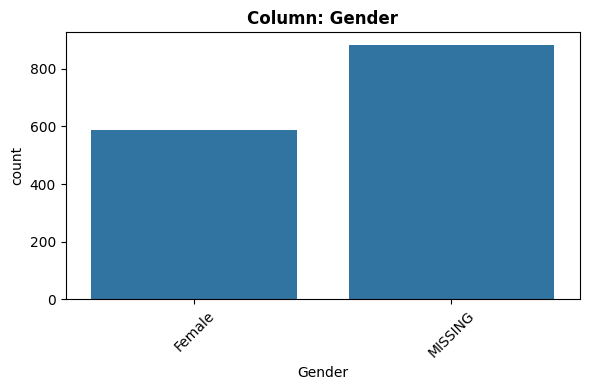

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'MISSING' occurs 882 times (60.0%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'Gender');

Using a countplot, we observe that around 60% of the `Gender` feature values are missing.  
We cannot ensure that all missing values are Male, so it is better to keep them marked as `MISSING`.

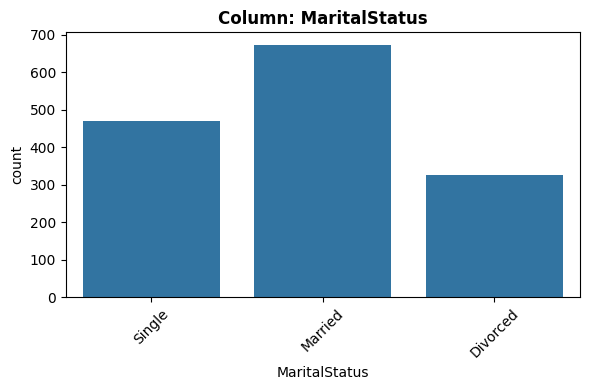

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Married' occurs 673 times (45.78%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'MaritalStatus');

By considering the countplot for `MaritalStatus`, we found that `Married` is the most frequent value in the data (around 45%), followed by `Single`, while `Divorced` is the least frequent.

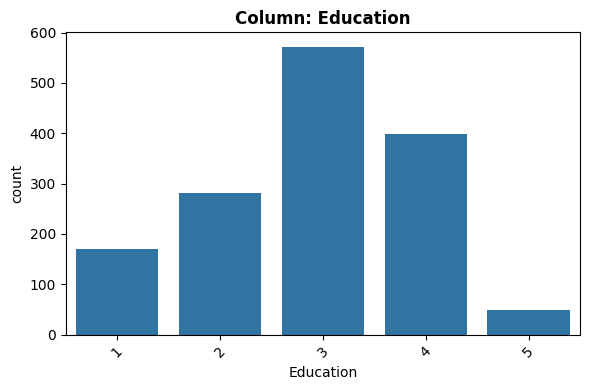

- NaN's Found: 0 (0.0%)
- Unique Values: 5
- Most common value: '3' occurs 572 times (38.91%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'Education');

We note that the most frequent value in `Education` is 3, which means Bachelor, followed by 4 (Master), then 2 (College), and 1 (Below College).  
The least frequent value is 5, which corresponds to Doctor.

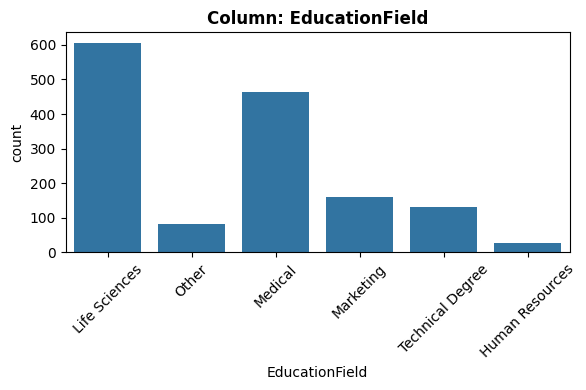

- NaN's Found: 0 (0.0%)
- Unique Values: 6
- Most common value: 'Life Sciences' occurs 606 times (41.22%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'EducationField');

The countplot for `EducationField` shows that the most frequent value in our data is `Life Sciences`, followed by `Medical`.  
The other fields occur less frequently and have similar counts.

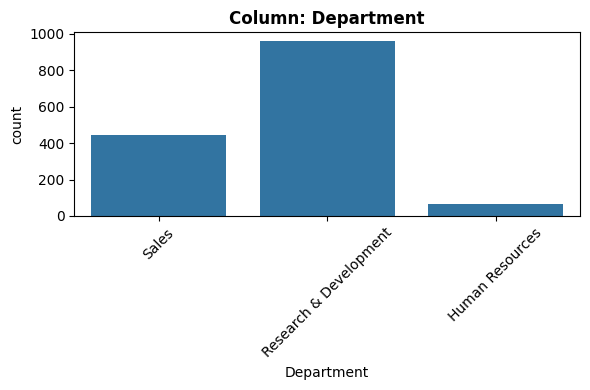

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Research & Development' occurs 961 times (65.37%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'Department');

From `Department`, we found that the most frequent value is `Research & Development`, which may be related to the distribution in `EducationField`.  
Specifically, `Human Resources` is the least frequent in both `Department` and `EducationField`.

In [ ]:
# Source: https://medium.com/@whyamit404/understanding-pandas-crosstab-with-simple-examples-90cf6ea5a9a1
pd.crosstab(df['Department'], df['EducationField'])

EducationField,Human Resources,Life Sciences,Marketing,Medical,Other,Technical Degree
Department,,,,,,
Human Resources,27,16,0,13,3,4
Research & Development,0,440,0,363,64,94
Sales,0,150,159,88,15,34


The cross-tab between `Department` and `EducationField` shows a clear link between employees' education and their department:

- HR mostly has employees with HR backgrounds.  
- R&D is dominated by Life Sciences and Medical fields.  
- Sales is more diverse, including Marketing, Life Sciences, and Medical backgrounds.  

Overall, employee placement generally aligns with their education, with strong specialization in HR and R&D, and more variety in Sales.

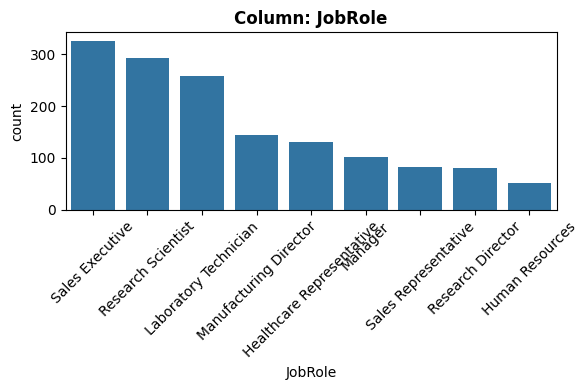

- NaN's Found: 0 (0.0%)
- Unique Values: 9
- Most common value: 'Sales Executive' occurs 326 times (22.18%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'JobRole');

For `JobRole`, the most frequent value is `Sales Executive`, followed by `Research Scientist`, while the least frequent is `Human Resources`.

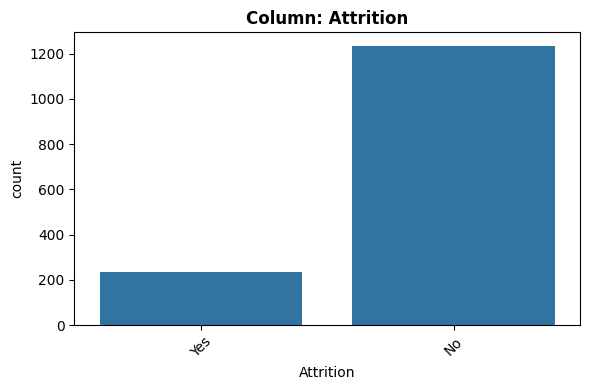

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'No' occurs 1233 times (83.88%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'Attrition');

Using a count plot for the `Attrition` feature, we observe that the majority of employees did not leave the company, with the "No" category occurring 1233 times (83.88%).

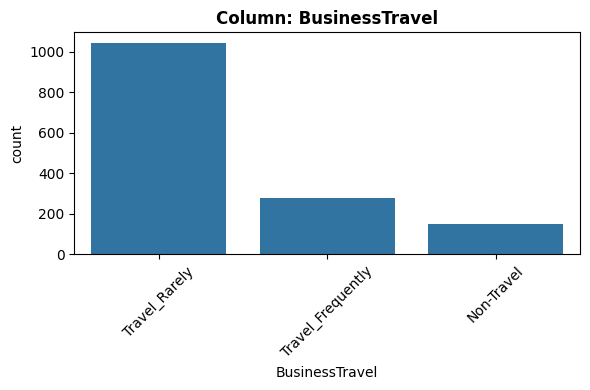

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Travel_Rarely' occurs 1043 times (70.95%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'BusinessTravel');

Using a count plot for the `BusinessTravel` feature, we observe that the most of employees travel rarely (70.95%).

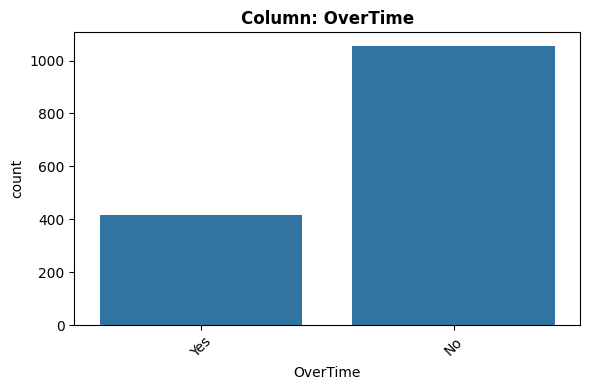

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'No' occurs 1054 times (71.7%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'OverTime');

The count plot for the `OverTime` feature shows that most employees do not work overtime. This feature may influence the target variable (`Attrition`), as employees who do not work overtime are less likely to leave the company, which may partially explain why the majority of `Attrition` values are "No".

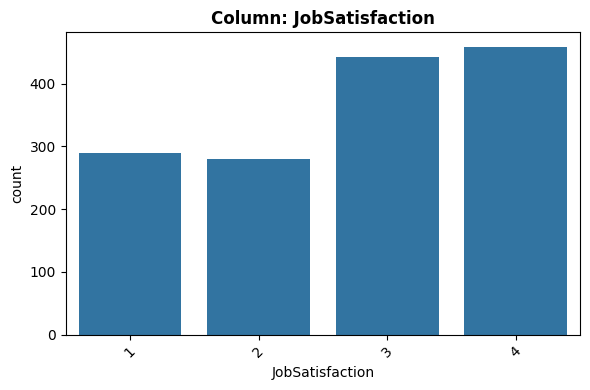

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: '4' occurs 459 times (31.22%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'JobSatisfaction');

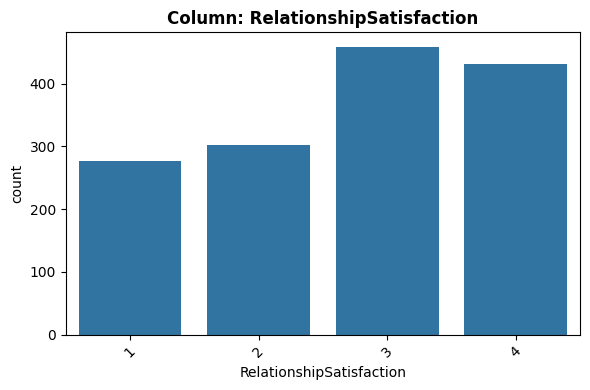

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: '3' occurs 459 times (31.22%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'RelationshipSatisfaction');

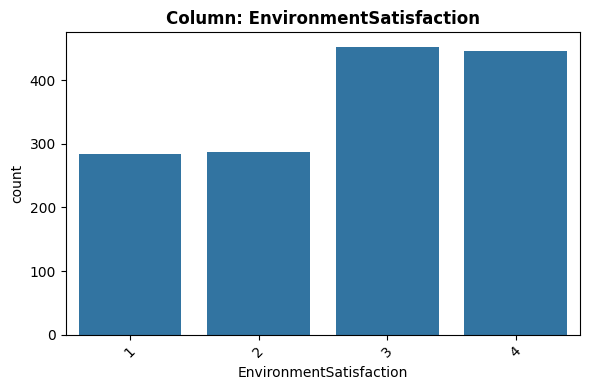

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: '3' occurs 453 times (30.82%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'EnvironmentSatisfaction');

For the features `RelationshipSatisfaction`, `EnvironmentSatisfaction`, and `JobSatisfaction`, higher values (3 and 4) occur more frequently than lower values (1 and 2).

This indicates that most employees report moderate to high satisfaction levels. These factors may influence the decision to leave the company, as higher satisfaction is generally associated with lower attrition.

In [ ]:
numeric_col = df.select_dtypes('number')
numeric_col.columns

Index(['EmployeeNumber', 'Age', 'DistanceFromHome', 'HourlyRate', 'DailyRate',
       'YearlyRate', 'PercentSalaryHike', 'NumCompaniesWorked',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

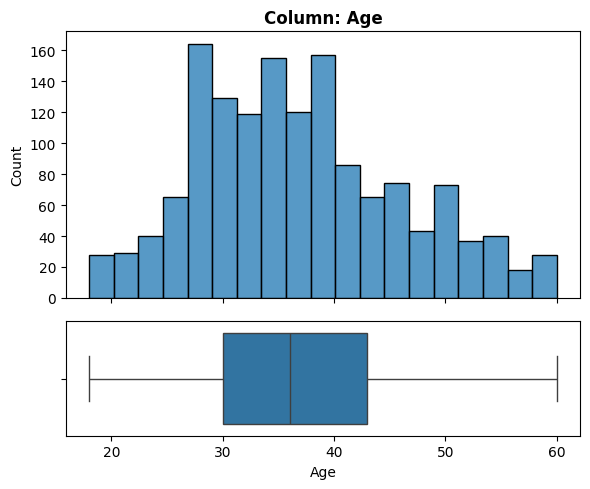

- NaN's Found: 0 (0.0%)
- Unique Values: 43
- Most common value: '35' occurs 78 times (5.31%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'Age');

The histogram of `Age` shows an approximately bell-shaped distribution with a slight right skew, indicating that younger employees are more common than older ones.

The interquartile range is approximately between 30 and 43–44 years, indicating that the middle 50% of employees fall within this range. No significant outliers are observed in the distribution.

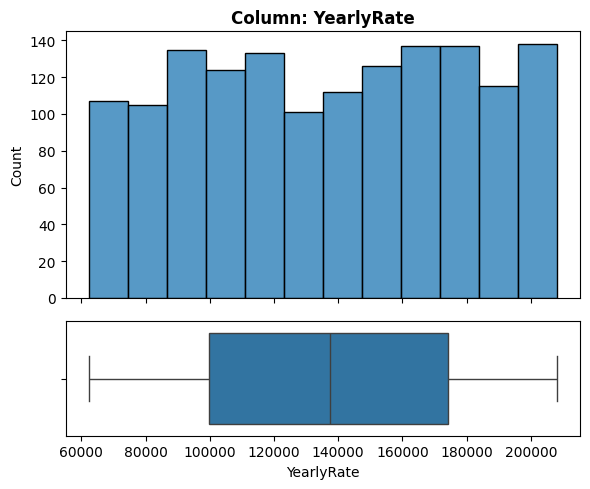

- NaN's Found: 0 (0.0%)
- Unique Values: 71
- Most common value: '137280' occurs 29 times (1.97%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'YearlyRate');

The histogram of `YearlyRate` shows that values are fairly evenly distributed across a wide range, with no strong concentration in a single interval.

Most values appear to be centered around the mid-range (approximately 130,000–140,000), which aligns with the median observed in the boxplot.

The boxplot indicates that the interquartile range lies roughly between 100,000 and 175,000. The overall data appears to span approximately from 60,000 to 200,000, with no significant outliers detected.

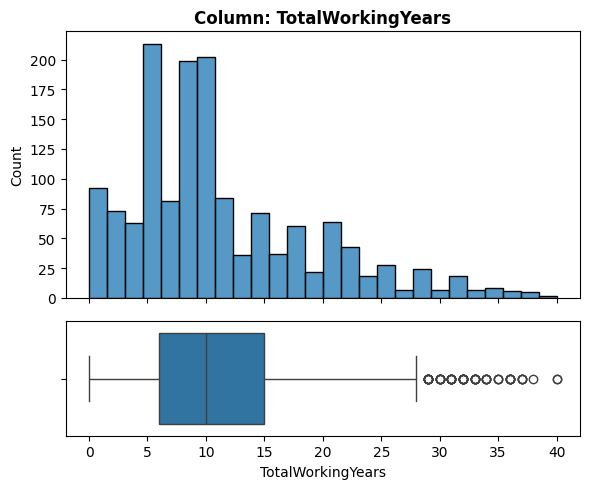

- NaN's Found: 0 (0.0%)
- Unique Values: 40
- Most common value: '10' occurs 202 times (13.74%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'TotalWorkingYears');

For the `TotalWorkingYears` feature, most employees have around 10 years of total work experience, which also corresponds to the median observed in the boxplot.

The interquartile range is approximately 6 to 15 years, while a few outliers have much higher experience, starting around 28–29 years. The maximum value reaches about 40 years, but most employees have relatively fewer total working years.

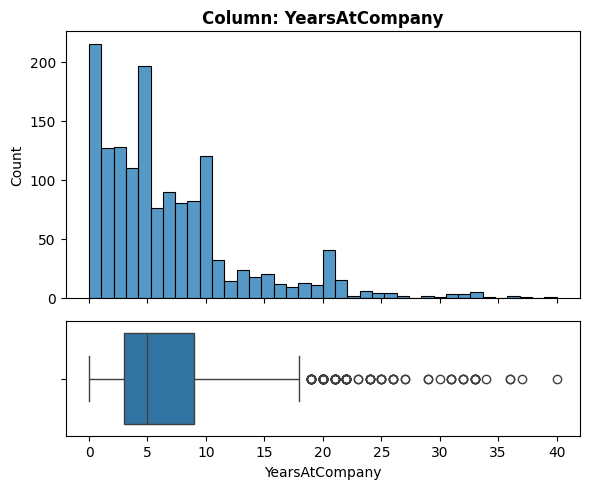

- NaN's Found: 0 (0.0%)
- Unique Values: 37
- Most common value: '5' occurs 196 times (13.33%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'YearsAtCompany');

For the `YearsAtCompany` feature, most employees have around 5 years at the company. The histogram is strongly right-skewed, with a long tail toward higher values.

Compared to `TotalWorkingYears`, which is also right-skewed, `YearsAtCompany` has a smaller interquartile range (approximately 4 to 9 years) and a lower median. A few outliers exist at higher values, reaching up to around 40 years, indicating that some employees have spent nearly their entire careers at the same company.

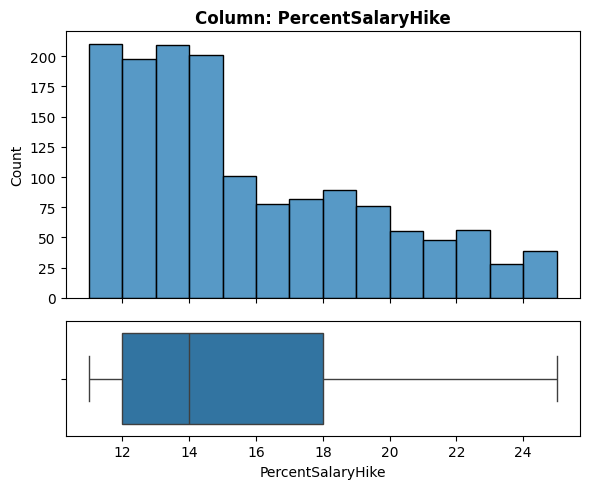

- NaN's Found: 0 (0.0%)
- Unique Values: 15
- Most common value: '11' occurs 210 times (14.29%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'PercentSalaryHike');

For the `PercentSalaryHike` feature, most employees received a salary increase of less than 15%.

The most common value is 11%, and the median is 14%, as shown in the boxplot.

The interquartile range (middle 50% of employees) is roughly between 12% and 18%. No significant outliers are observed.

This indicates that the most of employees received moderate salary increases, with very few extreme raises.

These moderate raises may influence employee decisions to stay or leave the company, as smaller increases could contribute to higher attrition.

## Explore relationships between features


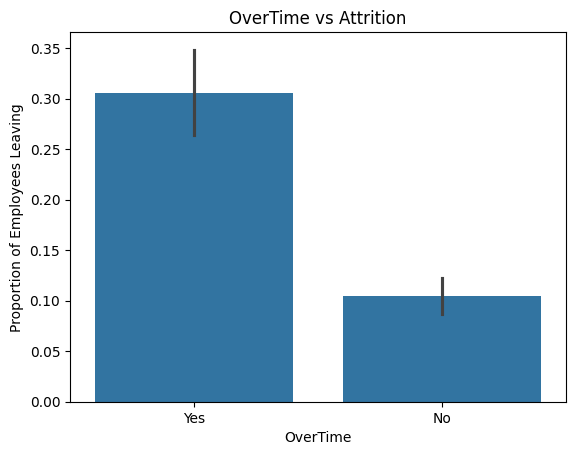

In [ ]:
sns.barplot(data=df, x='OverTime', y=df['Attrition'].map({'No':0,'Yes':1}))
plt.ylabel('Proportion of Employees Leaving')
plt.title('OverTime vs Attrition');

The barplot of `OverTime` vs `Attrition` shows that employees who work overtime are more likely to leave the company compared to those who do not. This indicates that OverTime is a critical feature influencing attrition.

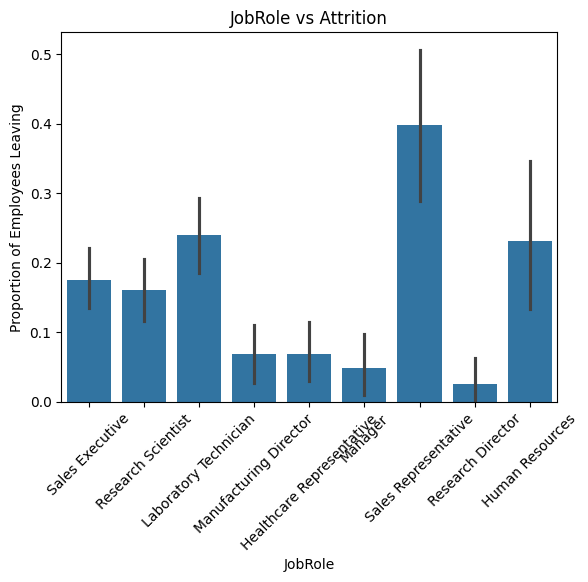

In [ ]:
ax = sns.barplot(data=df, x='JobRole', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('JobRole vs Attrition');

The barplot of `JobRole` vs `Attrition` shows that employees in the `Sales Representative` role have the highest likelihood of leaving the company, while those in `Research Director` roles have the lowest. This suggests that the type of job role may influence employee attrition, possibly due to job stress, responsibilities, or career growth opportunities.

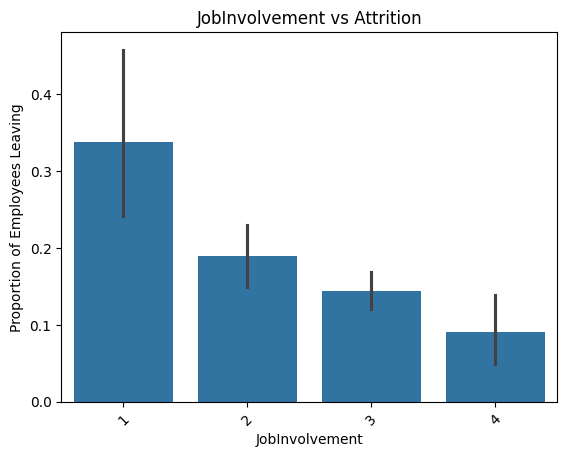

In [ ]:
ax = sns.barplot(data=df, x='JobInvolvement', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('JobInvolvement vs Attrition');

Employees with less Job Involvement are more likely to leave. Plot indicates negative correlation between Job Involvement and Attrition.

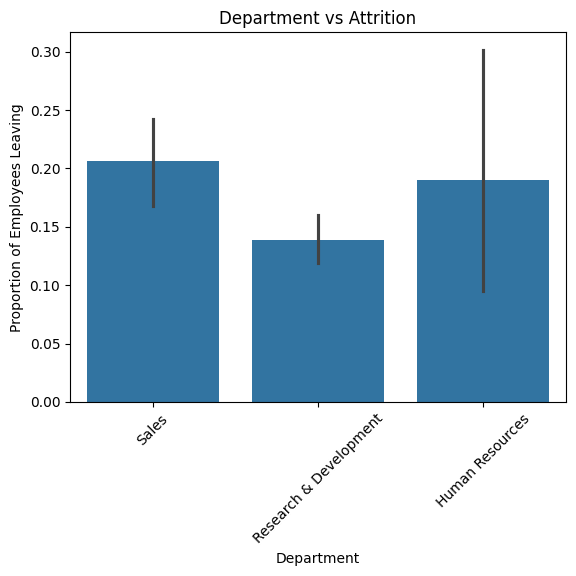

In [ ]:
ax = sns.barplot(data=df, x='Department', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('Department vs Attrition');

The barplot of `Department` vs `Attrition` shows that employees in the `Sales` department are the most likely to leave, followed by `Human Resources`, while `Research & Development` has the lowest attrition. This suggests that department-specific factors, such as job stress, workload, or career opportunities, may influence employee turnover.

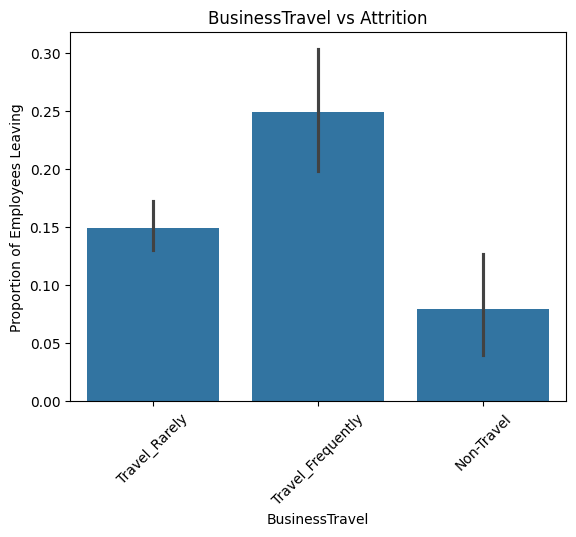

In [ ]:
ax = sns.barplot(data=df, x='BusinessTravel', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('BusinessTravel vs Attrition');

The barplot of `BusinessTravel` vs `Attrition` shows that employees who `travel frequently` are the most likely to leave the company, followed by those who `travel rarely`. Employees who do not travel have the lowest attrition.  

This suggests that **work-related travel demands** may increase job stress or reduce work-life balance, which could influence employee turnover.

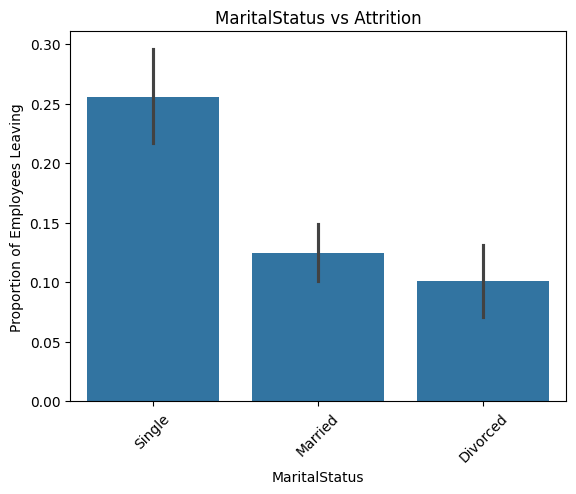

In [ ]:
ax = sns.barplot(data=df, x='MaritalStatus', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('MaritalStatus vs Attrition');

The barplot of `MaritalStatus` vs `Attrition` shows that **single employees** are more likely to leave the company compared to married or divorced employees.  

This may be because single employees typically have fewer personal or financial responsibilities, which could make them more flexible in changing jobs or seeking better opportunities.

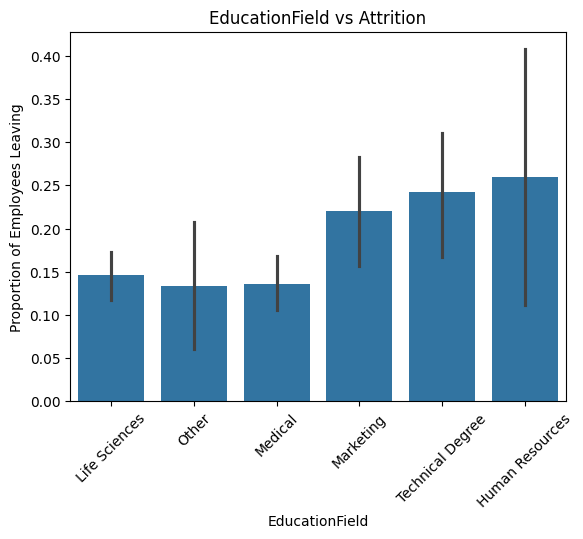

In [ ]:
ax = sns.barplot(data=df, x='EducationField', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('EducationField vs Attrition');

barplot shows that `Human Resources` and `Technical Degree` are more likey to leave, higher Attrition.

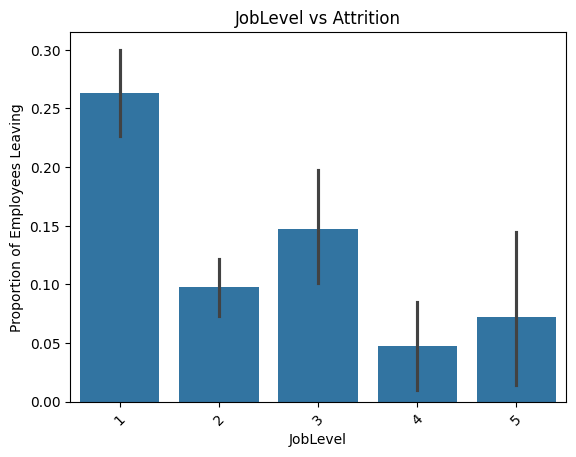

In [ ]:
ax = sns.barplot(data=df, x='JobLevel', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('JobLevel vs Attrition');

Plots shows employees with low level leave more than higher job level.

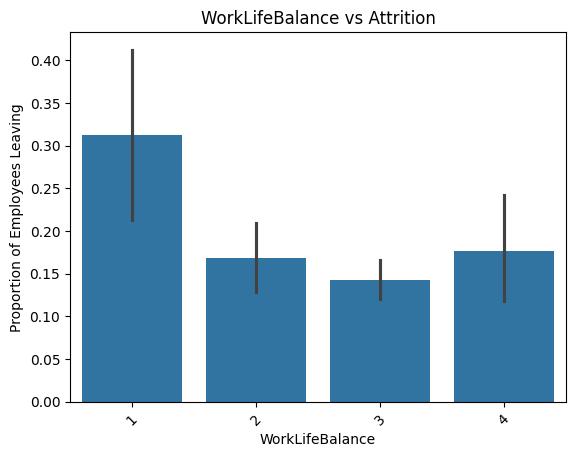

In [ ]:
ax = sns.barplot(data=df, x='WorkLifeBalance', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('WorkLifeBalance vs Attrition');

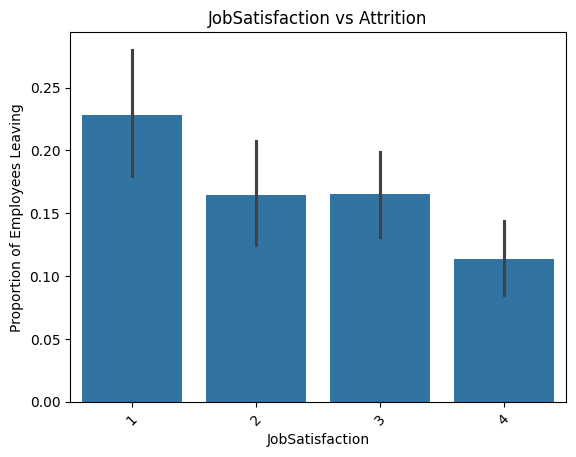

In [ ]:
ax = sns.barplot(data=df, x='JobSatisfaction', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('JobSatisfaction vs Attrition');

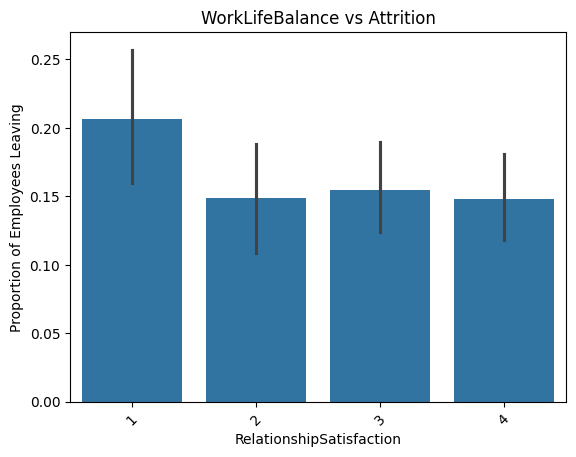

In [ ]:
ax = sns.barplot(data=df, x='RelationshipSatisfaction', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('WorkLifeBalance vs Attrition');

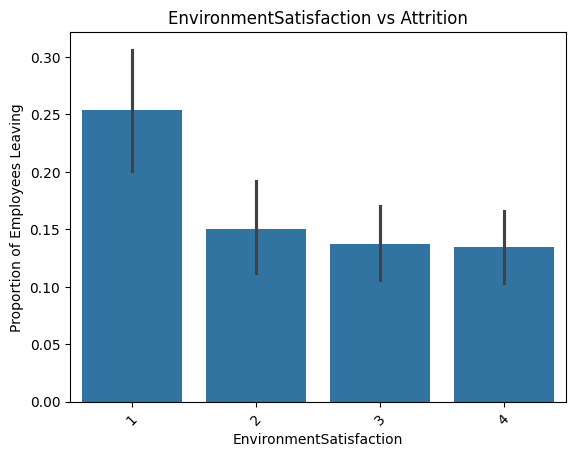

In [ ]:
ax = sns.barplot(data=df, x='EnvironmentSatisfaction', y=df['Attrition'].map({'No':0,'Yes':1}))
ax.tick_params(axis='x', rotation=45)
plt.ylabel('Proportion of Employees Leaving')
plt.title('EnvironmentSatisfaction vs Attrition');

As expected, the features `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, and `WorkLifeBalance` show higher attrition for employees with low scores (1), while higher scores correspond to lower attrition. This indicates that lower satisfaction and poorer work-life balance may influence employees' decisions to leave the company.

In [ ]:
corr = df.corr(numeric_only=True).round(2)
corr

,EmployeeNumber,Age,DistanceFromHome,HourlyRate,DailyRate,YearlyRate,PercentSalaryHike,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,1.00,-0.01,0.03,0.04,0.04,0.04,-0.01,-0.00,-0.01,0.02,-0.01,-0.01,-0.01,-0.01
Age,-0.01,1.00,-0.00,0.03,0.03,0.03,0.00,0.30,0.68,-0.02,0.30,0.21,0.22,0.20
DistanceFromHome,0.03,-0.00,1.00,0.03,0.03,0.03,0.04,-0.03,0.00,-0.04,0.01,0.02,0.01,0.01
HourlyRate,0.04,0.03,0.03,1.00,1.00,1.00,-0.01,0.02,-0.00,-0.01,-0.02,-0.02,-0.03,-0.02
DailyRate,0.04,0.03,0.03,1.00,1.00,1.00,-0.01,0.02,-0.00,-0.01,-0.02,-0.02,-0.03,-0.02
YearlyRate,0.04,0.03,0.03,1.00,1.00,1.00,-0.01,0.02,-0.00,-0.01,-0.02,-0.02,-0.03,-0.02
PercentSalaryHike,-0.01,0.00,0.04,-0.01,-0.01,-0.01,1.00,-0.01,-0.02,-0.01,-0.04,-0.00,-0.02,-0.01
NumCompaniesWorked,-0.00,0.30,-0.03,0.02,0.02,0.02,-0.01,1.00,0.24,-0.07,-0.12,-0.09,-0.04,-0.11
TotalWorkingYears,-0.01,0.68,0.00,-0.00,-0.00,-0.00,-0.02,0.24,1.00,-0.04,0.63,0.46,0.40,0.46
TrainingTimesLastYear,0.02,-0.02,-0.04,-0.01,-0.01,-0.01,-0.01,-0.07,-0.04,1.00,0.00,-0.01,-0.00,-0.00


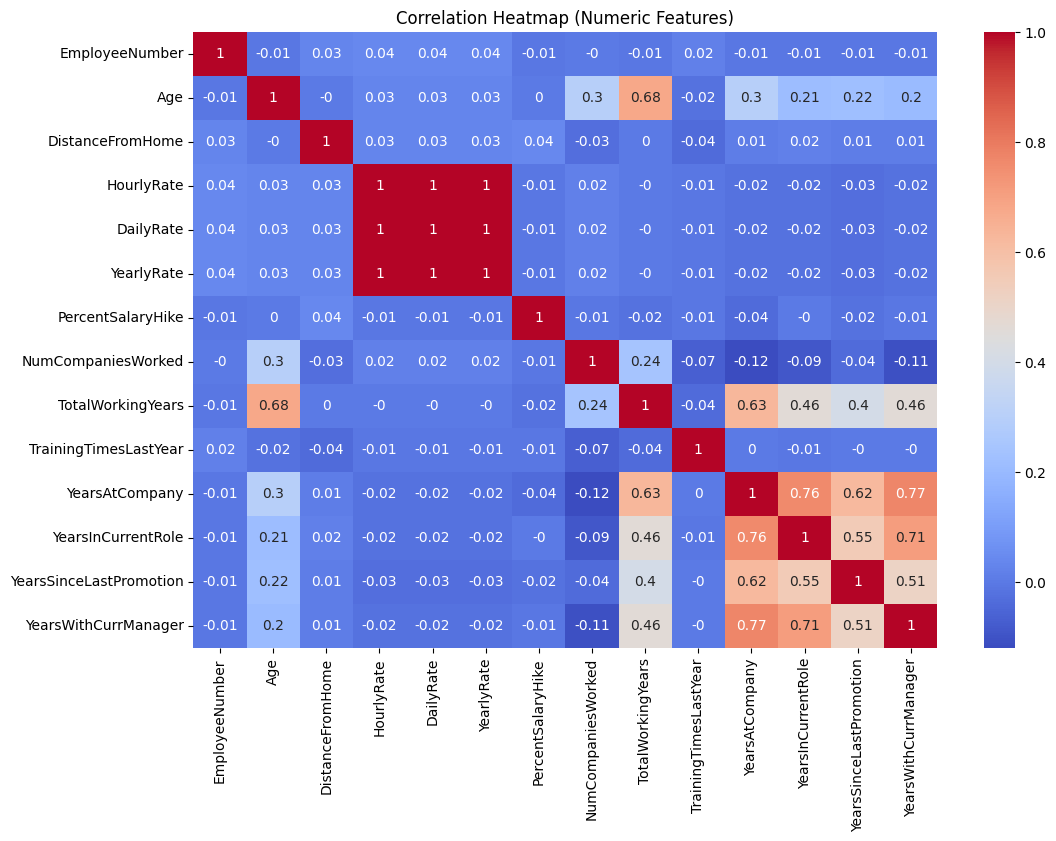

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
ax = sns.heatmap(corr, cmap='coolwarm', annot=True)
ax.set_title('Correlation Heatmap (Numeric Features)');

The heatmap provides several important insights about relationships between numeric features:

- `HourlyRate`, `DailyRate`, and `YearlyRate` show a very strong positive correlation (1.0), this suggests that they are derived from each other or represent the same information at different scales.  
  So we can say they are redundant features, and we can keep only one of them (`YearlyRate`).

- There is a strong positive correlation between `Age` and `TotalWorkingYears` (0.68), which is expected since older employees tend to have more work experience.

- We also observe strong correlations between:
  - `YearsAtCompany` and `YearsWithCurrManager`, `YearsInCurrentRole`, and `YearsSinceLastPromotion`
  - `YearsInCurrentRole` and `YearsWithCurrManager`
  Since all these features represent different aspects of experience within the company, this indicates overlap in the information.

- Additionally, `YearsAtCompany` and `TotalWorkingYears` show a strong correlation (0.63), meaning employees who have worked longer overall also tend to stay longer in the same company.

- `TotalWorkingYears` is also positively correlated with `YearsInCurrentRole` and `YearsWithCurrManager`.

- A moderate positive correlation is observed between `Age` and `NumCompaniesWorked` (0.3), suggesting that older employees have likely worked in more companies over time.

Overall, many "years" related features are highly correlated, which may introduce redundancy. This should be considered during feature selection or modeling.

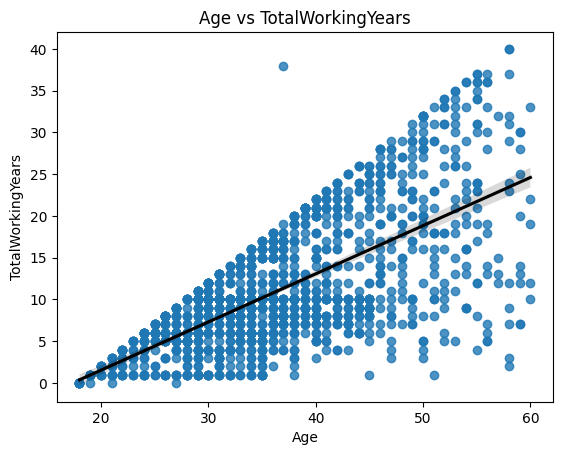

In [ ]:
line_kws = dict(color='black')
sns.regplot(data=df, x='Age', y='TotalWorkingYears', line_kws=line_kws)
plt.title('Age vs TotalWorkingYears');

Regplot commit the same relation we observe in heatmap, with a very clear trend line, shows an increasing slope between Age and TotalWorkingYears.

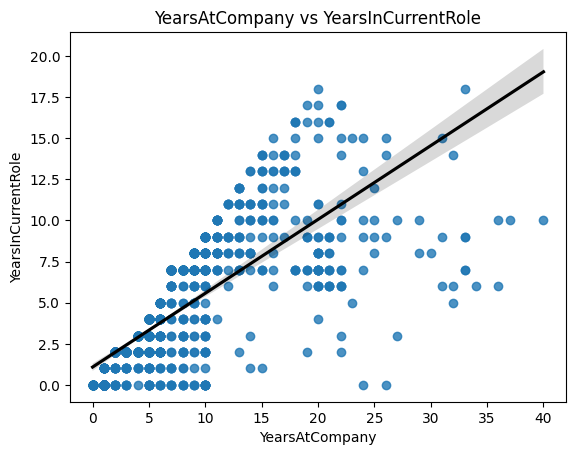

In [ ]:
line_kws = dict(color='black')
sns.regplot(data=df, x='YearsAtCompany', y='YearsInCurrentRole', line_kws=line_kws)
plt.title('YearsAtCompany vs YearsInCurrentRole');

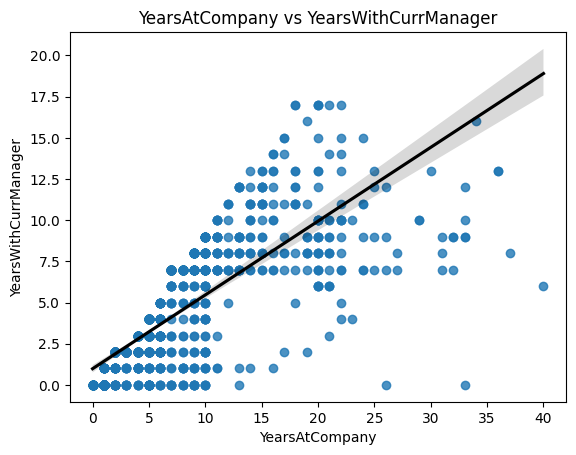

In [ ]:
line_kws = dict(color='black')
sns.regplot(data=df, x='YearsAtCompany', y='YearsWithCurrManager', line_kws=line_kws)
plt.title('YearsAtCompany vs YearsWithCurrManager');

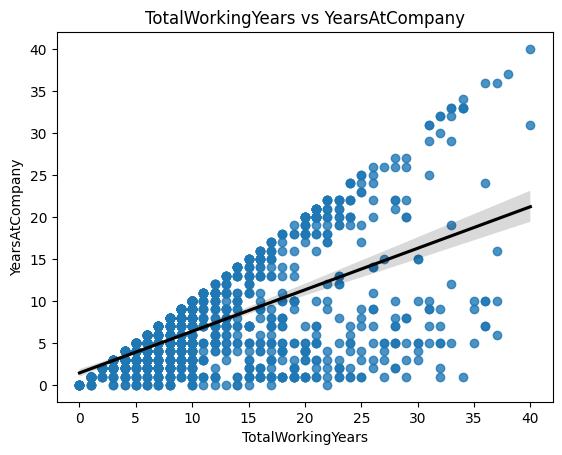

In [ ]:
line_kws = dict(color='black')
sns.regplot(data=df, x='TotalWorkingYears', y='YearsAtCompany', line_kws=line_kws)
plt.title('TotalWorkingYears vs YearsAtCompany');

Now, all 3 previous plots show also a strong relation with features related to years, we can observe that polt of `YearsAtCompany` vs `YearsInCurrentRole` and `YearsAtCompany` vs `YearsWithCurrManager` are almost the same.

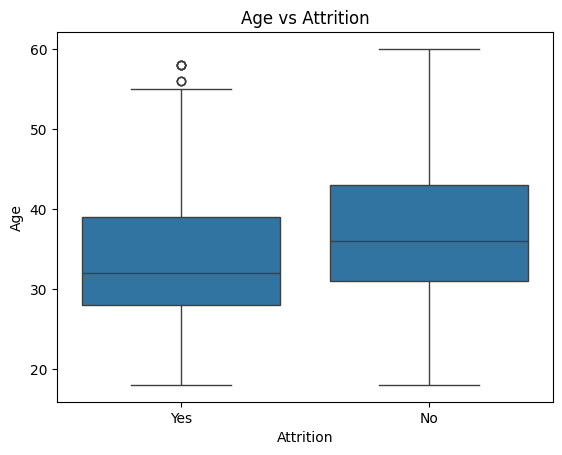

In [ ]:
sns.boxplot(data=df, x='Attrition', y='Age')
plt.title('Age vs Attrition');

Boxplot shows younger employees may leave more often.

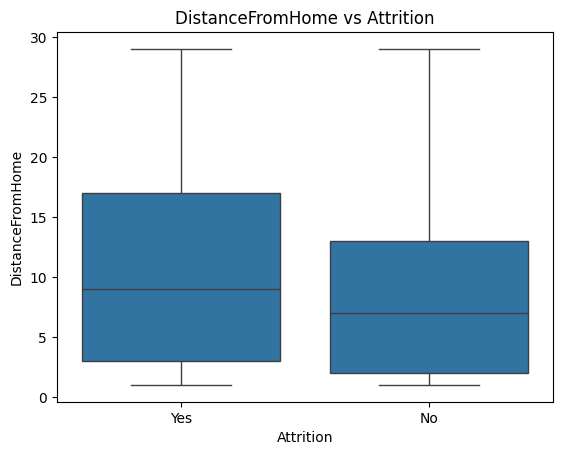

In [ ]:
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome')
plt.title('DistanceFromHome vs Attrition');

Employees with longer distance are more likely to leave, where appears with larger boxplot and higher median.

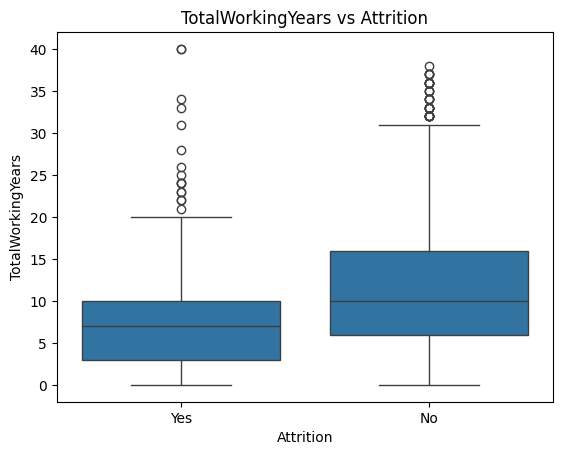

In [ ]:
sns.boxplot(data=df, x='Attrition', y='TotalWorkingYears')
plt.title('TotalWorkingYears vs Attrition');

Boxplot shows that employees with more experience (more work years) not likely to leave according with lower working year.

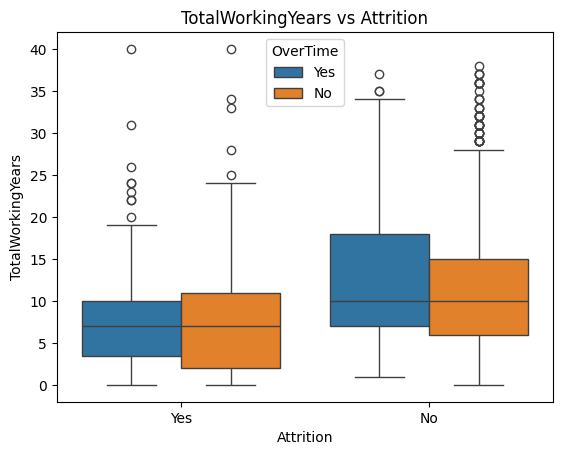

In [ ]:
sns.boxplot(data=df, x='Attrition', y='TotalWorkingYears', hue='OverTime')
plt.title('TotalWorkingYears vs Attrition');

Adding `OverTime` as hue in the boxplot of `TotalWorkingYears` vs `Attrition` shows that both employees with and without overtime have similar medians and distributions. This indicates that `TotalWorkingYears` does not vary significantly with `OverTime`, although `OverTime` itself still influences attrition independently.

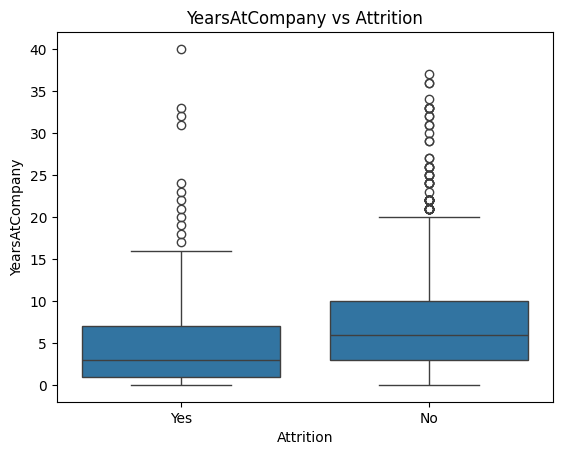

In [ ]:
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')
plt.title('YearsAtCompany vs Attrition');

YearsAtCompany is almost the same result as TotalWorkingYears, since employees less year are more likely to leave.

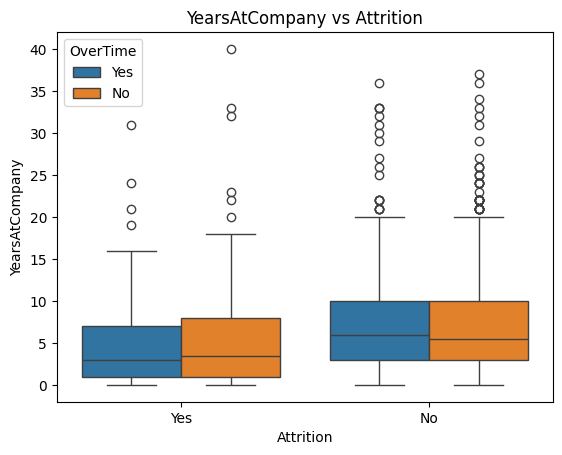

In [ ]:
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', hue='OverTime')
plt.title('YearsAtCompany vs Attrition');

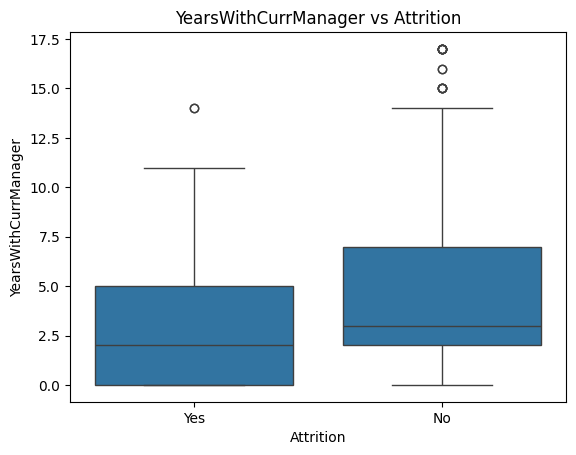

In [ ]:
sns.boxplot(data=df, x='Attrition', y='YearsWithCurrManager')
plt.title('YearsWithCurrManager vs Attrition');

The `YearsWithCurrManager` feature shows a relationship with attrition: employees with fewer years under their current manager are more likely to leave. This suggests that the manager-employee relationship may play a significant role in employee retention and stability.

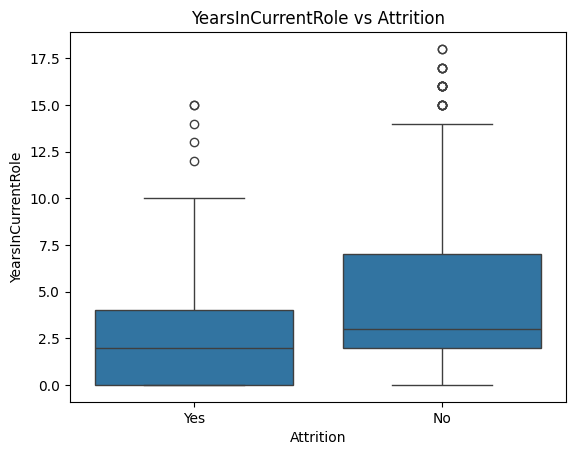

In [ ]:
sns.boxplot(data=df, x='Attrition', y='YearsInCurrentRole')
plt.title('YearsInCurrentRole vs Attrition');

Also `YearsInCurrentRole` showas same relation, that years in specific role can influence employee decision.

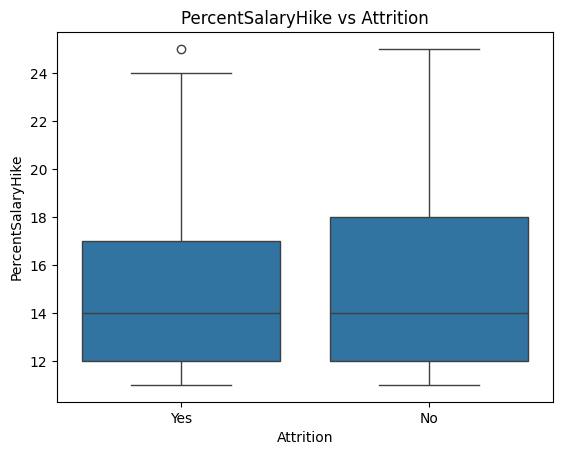

In [ ]:
sns.boxplot(data=df, x='Attrition', y='PercentSalaryHike')
plt.title('PercentSalaryHike vs Attrition');

An unexpected result is observed for `PercentSalaryHike`: employees who leave and those who stay have the same median and the same start of the boxplot. The “No” group shows a slightly higher upper end, indicating more variation. Contrary to expectation, a higher salary increase does not appear to reduce attrition in this dataset.

## Insights

- **Target (`Attrition`)**: Mostly `No` (~84%) and ~16% `Yes`

### Key Drivers of Attrition
- **OverTime**: Employees working overtime are more likely to leave (strong predictor)
- **JobRole**: Higher attrition in roles like `Sales Representative`, while roles like `Research Director` show lower attrition  
- **Department**: Sales shows higher attrition, followed by HR, then R&D, may reflect workload or role nature  
- **BusinessTravel**: Frequent travelers tend to leave more, travel stress may play a role
- **MaritalStatus**: Single employees show higher attrition, possible lifestyle or stability factors  
- **EducationField**: Higher attrition observed in HR & Technical fields compared to others.
- **JobLevel**: Lower-level employees are more likely to leave, seniority may increase stability  
- **Gender**: No clear pattern observed (note: high missing values limit reliability of this feature)  

### Numeric / Ordinal Features
- **Age**: Younger employees tend to leave more, early career instability  
- **DistanceFromHome**: trend where longer distance may increase attrition
- **TotalWorkingYears**: More experienced employees tend to stay longer  
- **YearsAtCompany**: Short tenure strongly associated with higher attrition  
- **YearsInCurrentRole / YearsWithCurrManager**: Lower values linked to higher attrition, role and manager stability influence attrition
- **PercentSalaryHike**: No clear separation, weak predictor alone  
- **Satisfaction features** (`JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance`): Lower values strongly associated with attrition, among the most important factors  

### Feature Relationships (Heatmap Insights)
- **Strong redundancy**:
  - `HourlyRate`, `DailyRate`, `YearlyRate`: highly correlated.  
- **Experience-related features are correlated**:
  - `Age` & `TotalWorkingYears` (strong)  
  - `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`: related tenure features  
- **Moderate correlation**:
  - `Age` & `NumCompaniesWorked`  


### Data Cleaning Actions Taken
- Removed duplicates  
- Fixed data types (`HourlyRate`, `YearsAtCompany`)  
- Handled outliers (e.g., invalid `Age`)  
- Imputed missing `Gender` with `MISSING`  
- Identified constant features (`EmployeeCount`, `StandardHours`, `Over18`)  
- Converted ordinal features to ordered categorical